In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import PowerTransformer

EDA

In [2]:
data=pd.read_csv(r"C:\Users\mdoba\Desktop\MTech-Codes\ML\credit_risk_dataset.csv")

In [3]:
data.describe()# statistical summary of the dataset

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [4]:
data.info()# data information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
data.isnull().sum()#checking for null values 

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [6]:
null_emp_length_entries = data[data['person_emp_length'].isnull()]
null_emp_length_entries

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
105,22,12600,MORTGAGE,NaN,PERSONAL,A,2000,5.42,1,0.16,N,4
222,24,185000,MORTGAGE,NaN,EDUCATION,B,35000,12.42,0,0.19,N,2
379,24,16800,MORTGAGE,NaN,DEBTCONSOLIDATION,A,3900,NaN,1,0.23,N,3
407,25,52000,RENT,NaN,PERSONAL,B,24000,10.74,1,0.46,N,2
408,22,17352,MORTGAGE,NaN,EDUCATION,C,2250,15.27,0,0.13,Y,3
...,...,...,...,...,...,...,...,...,...,...,...,...
32285,38,12000,OWN,NaN,EDUCATION,A,4800,7.29,1,0.40,N,12
32328,51,18408,RENT,NaN,PERSONAL,C,1000,14.65,1,0.05,Y,20
32360,70,39996,RENT,NaN,MEDICAL,C,3600,15.23,0,0.09,Y,19
32453,56,32400,RENT,NaN,MEDICAL,A,8575,7.51,0,0.26,N,18


In [7]:
loan_int_rate = data[data['loan_int_rate'].isnull()]
loan_int_rate  

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
39,23,71500,RENT,3.0,DEBTCONSOLIDATION,D,30000,NaN,1,0.42,N,4
50,24,78000,RENT,4.0,DEBTCONSOLIDATION,D,30000,NaN,1,0.38,Y,4
57,23,277000,OWN,3.0,PERSONAL,A,35000,NaN,0,0.13,N,4
59,24,12000,OWN,2.0,VENTURE,E,1750,NaN,0,0.15,Y,3
62,26,263000,MORTGAGE,0.0,EDUCATION,B,10000,NaN,1,0.04,N,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32547,53,4888,OWN,0.0,VENTURE,C,1400,NaN,1,0.29,Y,28
32552,65,45900,RENT,2.0,EDUCATION,C,10000,NaN,0,0.22,Y,19
32553,54,20000,RENT,2.0,MEDICAL,C,5000,NaN,0,0.25,N,28
32569,51,60000,MORTGAGE,1.0,PERSONAL,A,7500,NaN,0,0.13,N,23


In [8]:
unique_names = data['cb_person_default_on_file'].unique()
print("Unique names: ", unique_names)

Unique names:  ['Y' 'N']


In [9]:
data['person_home_ownership'] = data['person_home_ownership'].replace({'RENT': 1, 'MORTGAGE': 2, 'OWN':3,'OTHER':4})
data['loan_intent'] = data['loan_intent'].replace({'PERSONAL':1, 'EDUCATION':2, 'MEDICAL':3, 'VENTURE':4, 'HOMEIMPROVEMENT':5, 'DEBTCONSOLIDATION':6})
data['loan_grade'] = data['loan_grade'].replace({'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6,'G':7})
data['cb_person_default_on_file']=data['cb_person_default_on_file'].replace({'Y':1,'N':2})

In [10]:
# Imputing missing values with median
data=data.fillna(data.mean())#median())

In [11]:
# Imputing missing values with mean
data['person_emp_length'].fillna(data['person_emp_length'].median())#mean())
data['loan_int_rate'].fillna(data['loan_int_rate'].median())#mean())

0        16.02
1        11.14
2        12.87
3        15.23
4        14.27
         ...  
32576    13.16
32577     7.49
32578    10.99
32579    11.48
32580     9.99
Name: loan_int_rate, Length: 32581, dtype: float64

In [12]:
data.isnull().sum()#checking for null values after imputation

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [13]:
max_age = data['person_age'].max()
min_age = data['person_age'].min()
print(f"maximum Age {max_age}")
print(f"minimum Age {min_age}")


maximum Age 144
minimum Age 20


In [14]:
max_income = data['person_income'].max()
min_income = data['person_income'].min()

print(f"maximum Income {max_income}")
print(f"minimum Income {min_income}")

maximum Income 6000000
minimum Income 4000


array([[<Axes: title={'center': 'person_age'}>,
        <Axes: title={'center': 'person_income'}>,
        <Axes: title={'center': 'person_home_ownership'}>],
       [<Axes: title={'center': 'person_emp_length'}>,
        <Axes: title={'center': 'loan_intent'}>,
        <Axes: title={'center': 'loan_grade'}>],
       [<Axes: title={'center': 'loan_amnt'}>,
        <Axes: title={'center': 'loan_int_rate'}>,
        <Axes: title={'center': 'loan_status'}>],
       [<Axes: title={'center': 'loan_percent_income'}>,
        <Axes: title={'center': 'cb_person_default_on_file'}>,
        <Axes: title={'center': 'cb_person_cred_hist_length'}>]],
      dtype=object)

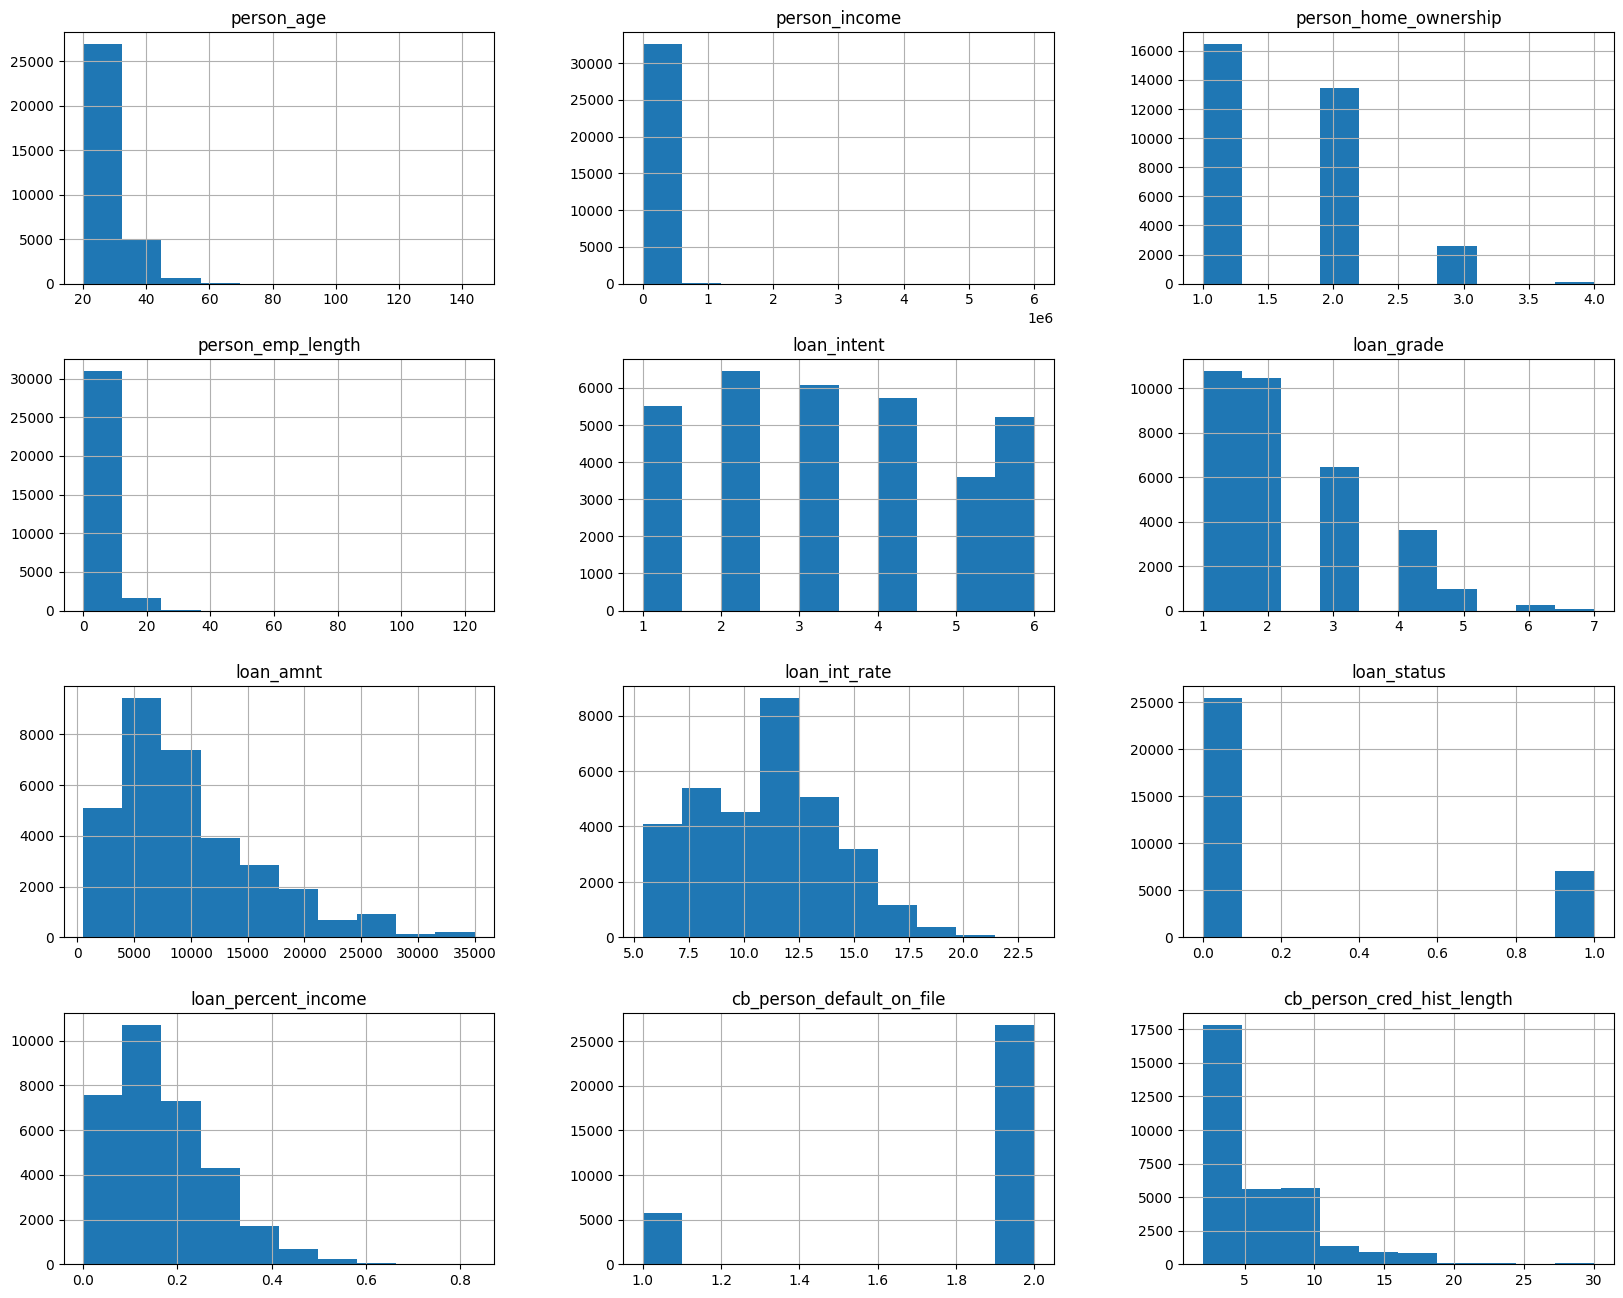

In [15]:
data.hist(figsize=(20, 16))

In [16]:
skew_vals=data.skew()
skew_vals

person_age                     2.581393
person_income                 32.865349
person_home_ownership          0.746013
person_emp_length              2.651118
loan_intent                    0.193253
loan_grade                     0.866563
loan_amnt                      1.192477
loan_int_rate                  0.219300
loan_status                    1.364888
loan_percent_income            1.064669
cb_person_default_on_file     -1.698687
cb_person_cred_hist_length     1.661790
dtype: float64

In [17]:
# Separate columns by skewness level
high_skew = skew_vals[skew_vals.abs() > 2].index
moderate_skew = skew_vals[(skew_vals.abs() > 0.5) & (skew_vals.abs() <= 2)].index

print("Highly skewed columns:", list(high_skew))
print("Moderately skewed columns:", list(moderate_skew))

# --- Transformations ---
# Highly skewed: log1p only for positive values
for col in high_skew:
    if (data[col] >= 0).all():   
        data[col] = np.log1p(data[col])
    else:
        # for negatives 
        pt = PowerTransformer(method='yeo-johnson')
        data[col] = pt.fit_transform(data[[col]])

# Moderately skewed: square root only for non-negative values
for col in moderate_skew:
    if (data[col] >= 0).all():
        data[col] = np.sqrt(data[col])
    else:
        # Yeo-Johnson again for negatives
        pt = PowerTransformer(method='yeo-johnson')
        data[col] = pt.fit_transform(data[[col]])

Highly skewed columns: ['person_age', 'person_income', 'person_emp_length']
Moderately skewed columns: ['person_home_ownership', 'loan_grade', 'loan_amnt', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


In [18]:
data.skew()

person_age                    1.241667
person_income                 0.155994
person_home_ownership         0.481535
person_emp_length            -0.485497
loan_intent                   0.193253
loan_grade                    0.404344
loan_amnt                     0.417025
loan_int_rate                 0.219300
loan_status                   1.364888
loan_percent_income           0.290953
cb_person_default_on_file    -1.698687
cb_person_cred_hist_length    0.896274
dtype: float64

array([[<Axes: title={'center': 'person_age'}>,
        <Axes: title={'center': 'person_income'}>,
        <Axes: title={'center': 'person_home_ownership'}>],
       [<Axes: title={'center': 'person_emp_length'}>,
        <Axes: title={'center': 'loan_intent'}>,
        <Axes: title={'center': 'loan_grade'}>],
       [<Axes: title={'center': 'loan_amnt'}>,
        <Axes: title={'center': 'loan_int_rate'}>,
        <Axes: title={'center': 'loan_status'}>],
       [<Axes: title={'center': 'loan_percent_income'}>,
        <Axes: title={'center': 'cb_person_default_on_file'}>,
        <Axes: title={'center': 'cb_person_cred_hist_length'}>]],
      dtype=object)

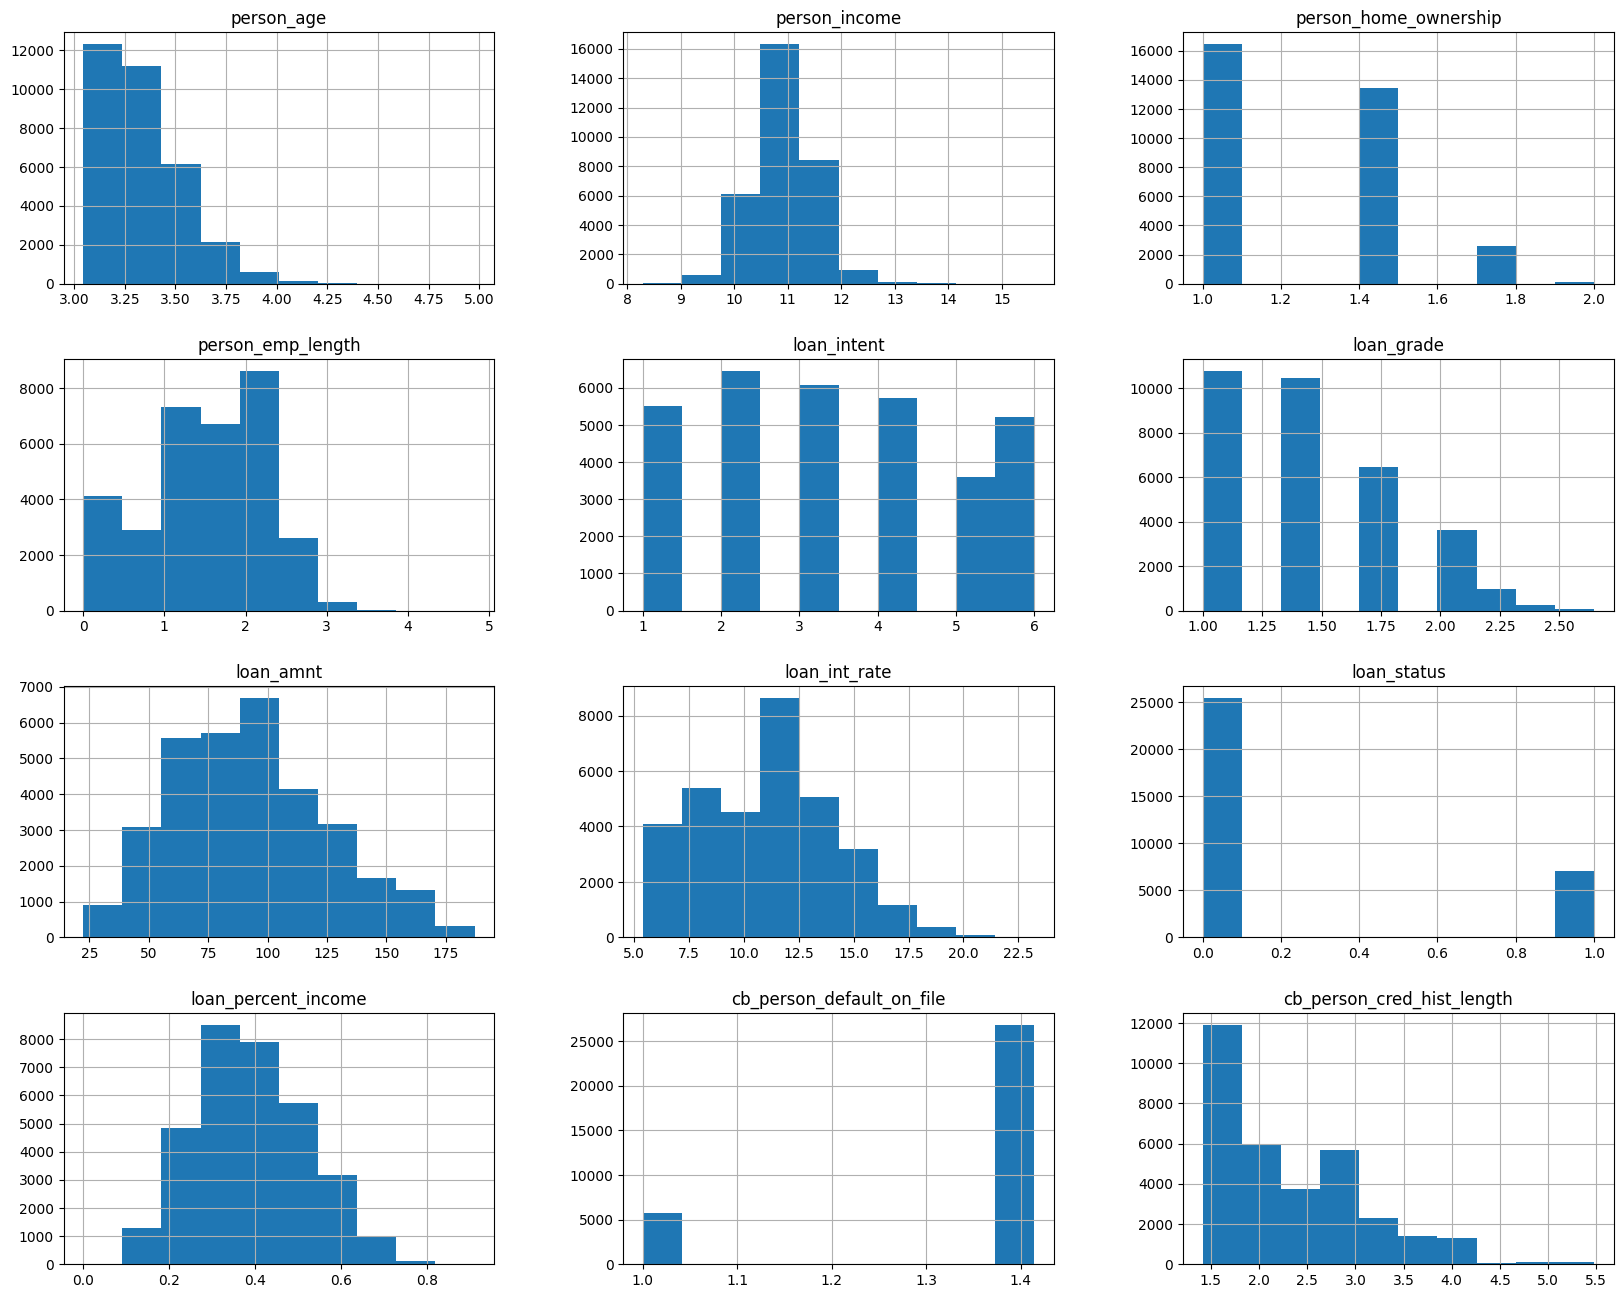

In [19]:
data.hist(figsize=(20,16))

C:\Users\mdoba\AppData\Local\Temp\ipykernel_9812\655456850.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


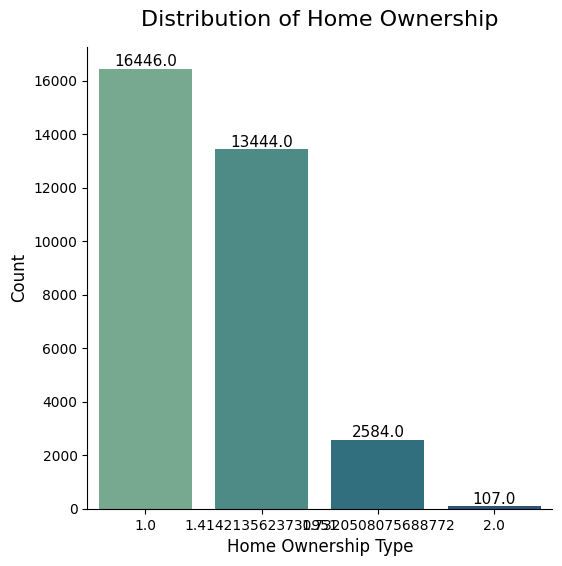

In [20]:
# Visualizing the distribution of home ownership types
custom_palette = sns.color_palette("crest", n_colors=data["person_home_ownership"].nunique())

plt.figure(figsize=(6,6))

ax = sns.countplot(
    x="person_home_ownership",
    data=data,
    palette=custom_palette,
    order=data["person_home_ownership"].value_counts().index
)


for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')


ax.set_title("Distribution of Home Ownership", fontsize=16, pad=15)
ax.set_xlabel("Home Ownership Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
sns.despine()

plt.show()

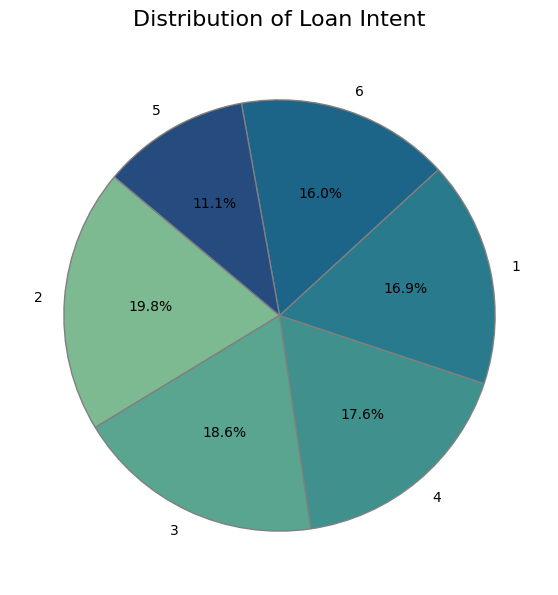

In [21]:
# Visualizing the distribution of loan intent
loan_counts = data["loan_intent"].value_counts()


colors = sns.color_palette("crest", n_colors=len(loan_counts))


plt.figure(figsize=(7,7))
plt.pie(
    loan_counts.values,
    labels=loan_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor':'gray', 'linewidth':1})

plt.title("Distribution of Loan Intent", fontsize=16, pad=15)
plt.show()

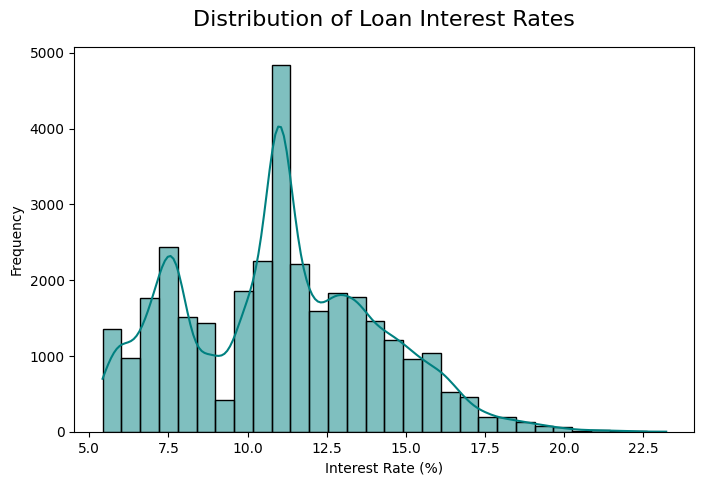

In [22]:
# Visualizing the distribution of loan interest rates
plt.figure(figsize=(8,5))
sns.histplot(data["loan_int_rate"], kde=True, color="teal", bins=30)
plt.title("Distribution of Loan Interest Rates", fontsize=16, pad=15)
plt.xlabel("Interest Rate (%)")
plt.ylabel("Frequency")
plt.show()

# Logistic Regression


In [23]:
# Dataset splitting
split_data = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=3)
for train_index, test_index in split_data.split(data, data['loan_status']):
    train_set = data.loc[train_index]
    test_set = data.loc[test_index]

In [24]:
print(train_set.shape, test_set.shape)
print(train_set['loan_status'].value_counts())
print(test_set['loan_status'].value_counts())

(26064, 12) (6517, 12)
loan_status
0.0    20378
1.0     5686
Name: count, dtype: int64
loan_status
0.0    5095
1.0    1422
Name: count, dtype: int64


In [25]:
#splitting features and target variable for train set data
Ftrs_train = train_set.drop(columns='loan_status', axis=1)
Trgt_train = train_set['loan_status']

#splitting for test set data
Ftrs_test = test_set.drop(columns='loan_status', axis=1)
Trgt_test = test_set['loan_status']
#checking the split
print(Ftrs_train.shape, Trgt_train.shape)
print(Ftrs_test.shape, Trgt_test.shape)

(26064, 11) (26064,)
(6517, 11) (6517,)


In [26]:
# X_train: Training features, y_train: Training target labels
model = LogisticRegression()
model.fit(Ftrs_train, Trgt_train)
Trgt_pred = model.predict(Ftrs_train)
accuracy = accuracy_score(Trgt_train,Trgt_pred)
print("Accuracy score on train set:", accuracy)
Trgt_pred = model.predict(Ftrs_test) #predicting on test set for evaluation
accuracy = accuracy_score(Trgt_test,Trgt_pred)
print("Accuracy score on test set:", accuracy)

Accuracy score on train set: 0.8464548802946593
Accuracy score on test set: 0.8459413840724259


c:\Users\mdoba\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
print("Confuion matrix\n",confusion_matrix(Trgt_test,Trgt_pred))
print("\nClassification report\n",classification_report(Trgt_test,Trgt_pred))

Confuion matrix
 [[4826  269]
 [ 735  687]]

Classification report
               precision    recall  f1-score   support

         0.0       0.87      0.95      0.91      5095
         1.0       0.72      0.48      0.58      1422

    accuracy                           0.85      6517
   macro avg       0.79      0.72      0.74      6517
weighted avg       0.84      0.85      0.83      6517



Here's a detailed interpretation of your classification report for **class 0 (non-fraud)** and **class 1 (fraud)**:

---

## 🔍 Class-wise Performance Breakdown

| Class | Precision | Recall | F1-Score | Support | Interpretation |
|-------|-----------|--------|----------|---------|----------------|
| **0.0** (Non-Fraud) | 0.87 | 0.95 | 0.91 | 5095 | The model is excellent at identifying non-fraud cases. High recall (95%) means most legitimate transactions are correctly classified. Precision (87%) shows few false positives. |
| **1.0** (Fraud)     | 0.72 | 0.48 | 0.58 | 1422 | The model struggles with fraud detection. Only 48% of actual frauds are caught (low recall), and 28% of predicted frauds are incorrect (precision = 72%). F1-score of 0.58 reflects this imbalance. |

---

## 📊 Overall Metrics

- **Accuracy**: 85% — misleading due to class imbalance (majority class dominates).
- **Macro Avg**: Averages metrics equally across classes — shows weaker performance on minority class.
- **Weighted Avg**: Accounts for support (sample count) — dominated by class 0.

---

## ⚠️ Key Insight

- **High accuracy does not mean good fraud detection.**
- The model is biased toward predicting non-fraud due to class imbalance.
- **Low recall for class 1** means many fraudulent transactions are missed — a critical issue in fraud detection.

---

## ✅ What to Do Next

- Use **class weighting** or **resampling** to balance the training data.
- Optimize for **recall** on class 1 — missing fraud is costlier than flagging a legitimate transaction.
- Tune the **decision threshold** using the **precision-recall curve** to prioritize catching fraud.

Would you like help visualizing the precision-recall curve or adjusting the threshold to improve fraud recall?


### weghted log loss

In [35]:
weights = {0: 2, 1: 5}  # Weight 10 for class 1 (minority class)
weighted_lr_model = LogisticRegression(random_state=42, class_weight=weights)
weighted_lr_model.fit(Ftrs_train, Trgt_train)
y_pred_weighted_lr = weighted_lr_model.predict(Ftrs_test)

# Evaluate the weighted model
print(classification_report(Trgt_test, y_pred_weighted_lr))

              precision    recall  f1-score   support

         0.0       0.91      0.83      0.87      5095
         1.0       0.54      0.70      0.61      1422

    accuracy                           0.81      6517
   macro avg       0.73      0.77      0.74      6517
weighted avg       0.83      0.81      0.81      6517



c:\Users\mdoba\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training set size: (26064, 11), Test set size: (6517, 11)
Class distribution (train): [20378  5686]
Fraud ratio (train): 21.82%
Weight ratio: w1 = 3.58, w0 = 1
Epoch    0 | Weighted Loss: 1.08387
Epoch  100 | Weighted Loss: 0.76369
Epoch  200 | Weighted Loss: 0.75276
Epoch  300 | Weighted Loss: 0.75063
Epoch  400 | Weighted Loss: 0.74989
Epoch  500 | Weighted Loss: 0.74949
Epoch  600 | Weighted Loss: 0.74922
Epoch  700 | Weighted Loss: 0.74902
Epoch  800 | Weighted Loss: 0.74888
Epoch  900 | Weighted Loss: 0.74877
Epoch 1000 | Weighted Loss: 0.74868
Epoch 1100 | Weighted Loss: 0.74862
Epoch 1200 | Weighted Loss: 0.74857
Epoch 1300 | Weighted Loss: 0.74854
Epoch 1400 | Weighted Loss: 0.74851
Epoch 1500 | Weighted Loss: 0.74849
Epoch 1600 | Weighted Loss: 0.74847
Epoch 1700 | Weighted Loss: 0.74846
Epoch 1800 | Weighted Loss: 0.74844
Epoch 1900 | Weighted Loss: 0.74844


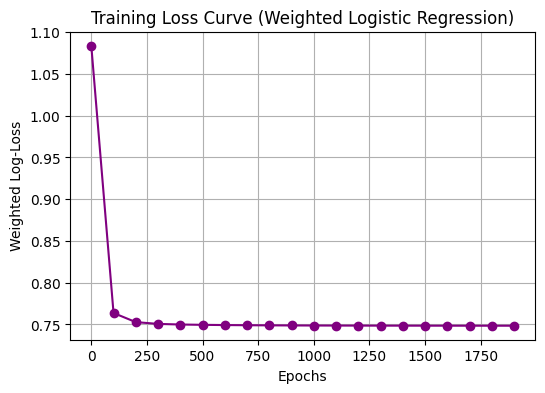


Confusion Matrix:
[[3912 1183]
 [ 319 1103]]

Classification Report:
              precision    recall  f1-score   support

         0.0      0.925     0.768     0.839      5095
         1.0      0.483     0.776     0.595      1422

    accuracy                          0.770      6517
   macro avg      0.704     0.772     0.717      6517
weighted avg      0.828     0.770     0.786      6517

ROC-AUC Score: 0.8451


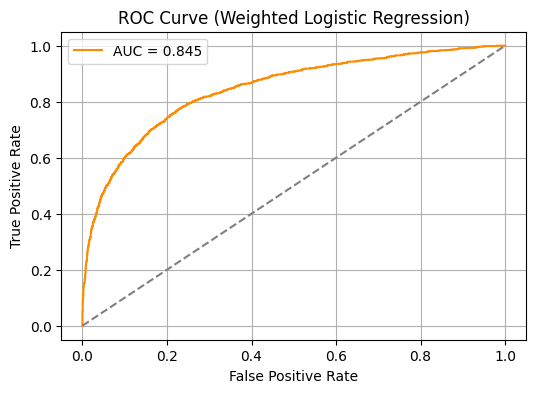

In [43]:
# =========================================================
# 🧠 WEIGHTED LOGISTIC REGRESSION FOR FRAUD DETECTION
# =========================================================
# In fraud detection, false negatives (missed frauds)
# are much more costly than false positives.
# We implement a weighted log-loss and derive its gradient.
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# ---------------------------------------------------------
# 1️⃣ LOAD EXISTING SPLIT DATASETS
# ---------------------------------------------------------
# Using your predefined variables:
# Ftrs_train, Trgt_train, Ftrs_test, Trgt_test

X_train, y_train = Ftrs_train.copy(), Trgt_train.copy()
X_test, y_test = Ftrs_test.copy(), Trgt_test.copy()

# Standardize features for better convergence
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")
print(f"Class distribution (train): {np.bincount(y_train)}")
print(f"Fraud ratio (train): {np.mean(y_train)*100:.2f}%")

# ---------------------------------------------------------
# 2️⃣ DEFINE SIGMOID AND WEIGHTED LOG-LOSS
# ---------------------------------------------------------

def sigmoid(z):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-z))

def weighted_log_loss(y, p, w0, w1):
    """Weighted binary cross-entropy loss"""
    loss = -np.mean(w1 * y * np.log(p + 1e-9) + w0 * (1 - y) * np.log(1 - p + 1e-9))
    return loss

# ---------------------------------------------------------
# 3️⃣ GRADIENT OF WEIGHTED LOG-LOSS
# ---------------------------------------------------------

def weighted_log_loss_grad(X, y, p, w0, w1):
    """
    Gradient of weighted log-loss with respect to w and b
    """
    n = len(y)
    weights = np.where(y == 1, w1, w0)
    diff = weights * (p - y)
    dw = (1 / n) * np.dot(X.T, diff)
    db = (1 / n) * np.sum(diff)
    return dw, db

# ---------------------------------------------------------
# 4️⃣ TRAINING FUNCTION (GRADIENT DESCENT)
# ---------------------------------------------------------

def train_weighted_logistic(X, y, w0=1.0, w1=10.0, alpha=0.01, epochs=2000):
    """
    Train logistic regression using weighted log-loss
    w0: weight for normal class (non-fraud)
    w1: weight for fraud class
    alpha: learning rate
    epochs: iterations
    """
    n, m = X.shape
    w = np.zeros(m)
    b = 0
    loss_history = []

    for i in range(epochs):
        z = np.dot(X, w) + b
        p = sigmoid(z)
        
        dw, db = weighted_log_loss_grad(X, y, p, w0, w1)
        
        # Gradient descent update
        w -= alpha * dw
        b -= alpha * db
        
        if i % 100 == 0:
            loss = weighted_log_loss(y, p, w0, w1)
            loss_history.append(loss)
            print(f"Epoch {i:4d} | Weighted Loss: {loss:.5f}")
    
    return w, b, loss_history

# ---------------------------------------------------------
# 5️⃣ COMPUTE CLASS WEIGHTS
# ---------------------------------------------------------

N0 = (y_train == 0).sum()
N1 = (y_train == 1).sum()
w0 = 1
w1 = N0 / N1  # emphasize fraud class

print(f"Weight ratio: w1 = {w1:.2f}, w0 = {w0}")

# ---------------------------------------------------------
# 6️⃣ TRAIN MODEL
# ---------------------------------------------------------

w, b, loss_history = train_weighted_logistic(X_train, y_train, w0=w0, w1=w1, alpha=0.06, epochs=2000)

# ---------------------------------------------------------
# 7️⃣ VISUALIZE TRAINING LOSS
# ---------------------------------------------------------

plt.figure(figsize=(6,4))
plt.plot(np.arange(0, len(loss_history)*100, 100), loss_history, '-o', color='purple')
plt.title("Training Loss Curve (Weighted Logistic Regression)")
plt.xlabel("Epochs")
plt.ylabel("Weighted Log-Loss")
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 8️⃣ EVALUATE MODEL ON TEST SET
# ---------------------------------------------------------


p_pred = sigmoid(np.dot(X_test, w) + b)
y_pred = (p_pred >= 0.5).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))
print(f"ROC-AUC Score: {roc_auc_score(y_test, p_pred):.4f}")

# ---------------------------------------------------------
# 9️⃣ ROC CURVE VISUALIZATION
# ---------------------------------------------------------

fpr, tpr, _ = roc_curve(y_test, p_pred)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, p_pred):.3f}", color='darkorange')
plt.plot([0,1], [0,1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Weighted Logistic Regression)")
plt.legend()
plt.grid(True)
plt.show()




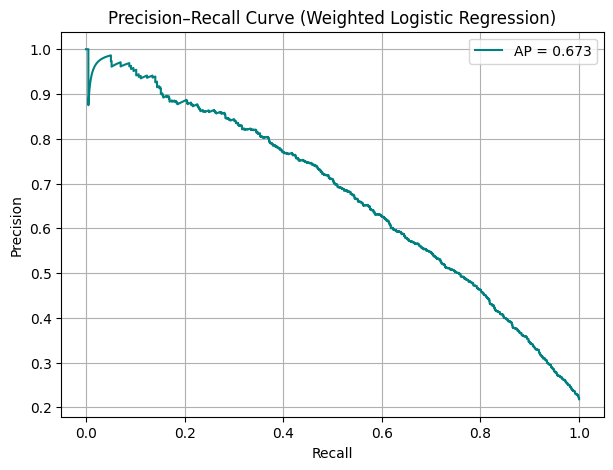

Threshold achieving ≥80% recall:
  Threshold = 0.0008
  Recall = 1.000
  Precision = 0.218

Confusion Matrix (Threshold 0.001):
[[   0 5095]
 [   0 1422]]

Classification Report (Threshold 0.001):
              precision    recall  f1-score   support

         0.0      0.000     0.000     0.000      5095
         1.0      0.218     1.000     0.358      1422

    accuracy                          0.218      6517
   macro avg      0.109     0.500     0.179      6517
weighted avg      0.048     0.218     0.078      6517



c:\Users\mdoba\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\mdoba\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\mdoba\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [ ]:
# ---------------------------------------------------------
# 🔟 PRECISION-RECALL CURVE & THRESHOLD ANALYSIS
# ---------------------------------------------------------
from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute precision-recall pairs for different probability thresholds
precision, recall, thresholds = precision_recall_curve(y_test, p_pred)
ap_score = average_precision_score(y_test, p_pred)

# Plot Precision–Recall curve
plt.figure(figsize=(7,5))
plt.plot(recall, precision, color='teal', label=f"AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Weighted Logistic Regression)")
plt.grid(True)
plt.legend()
plt.show()

# ---------------------------------------------------------
# 🧠 FIND THRESHOLD FOR RECALL ≥ 0.8
# ---------------------------------------------------------
target_recall = 0.80

# Find first threshold where recall >= 0.8
idx = np.argmax(recall >= target_recall)
best_threshold = thresholds[idx]
best_recall = recall[idx]
best_precision = precision[idx]

print(f"Threshold achieving ≥{target_recall*100:.0f}% recall:")
print(f"  Threshold = {best_threshold:.4f}")
print(f"  Recall = {best_recall:.3f}")
print(f"  Precision = {best_precision:.3f}")

# ---------------------------------------------------------
# ⚖️ Evaluate Model at This Threshold
# ---------------------------------------------------------
y_pred_custom = (p_pred >= best_threshold).astype(int)

print("\nConfusion Matrix (Threshold {:.3f}):".format(best_threshold))
print(confusion_matrix(y_test, y_pred_custom))
print("\nClassification Report (Threshold {:.3f}):".format(best_threshold))
print(classification_report(y_test, y_pred_custom, digits=3))
